# Line Detection by Convolution (Directional Kernels)
Uses adaptive mean thresholding + skeletonization, then convolves with oriented line kernels (0°, 45°, 90°, 135°) to detect lines in each direction. Peaks in the response maps indicate line pixels at that orientation.

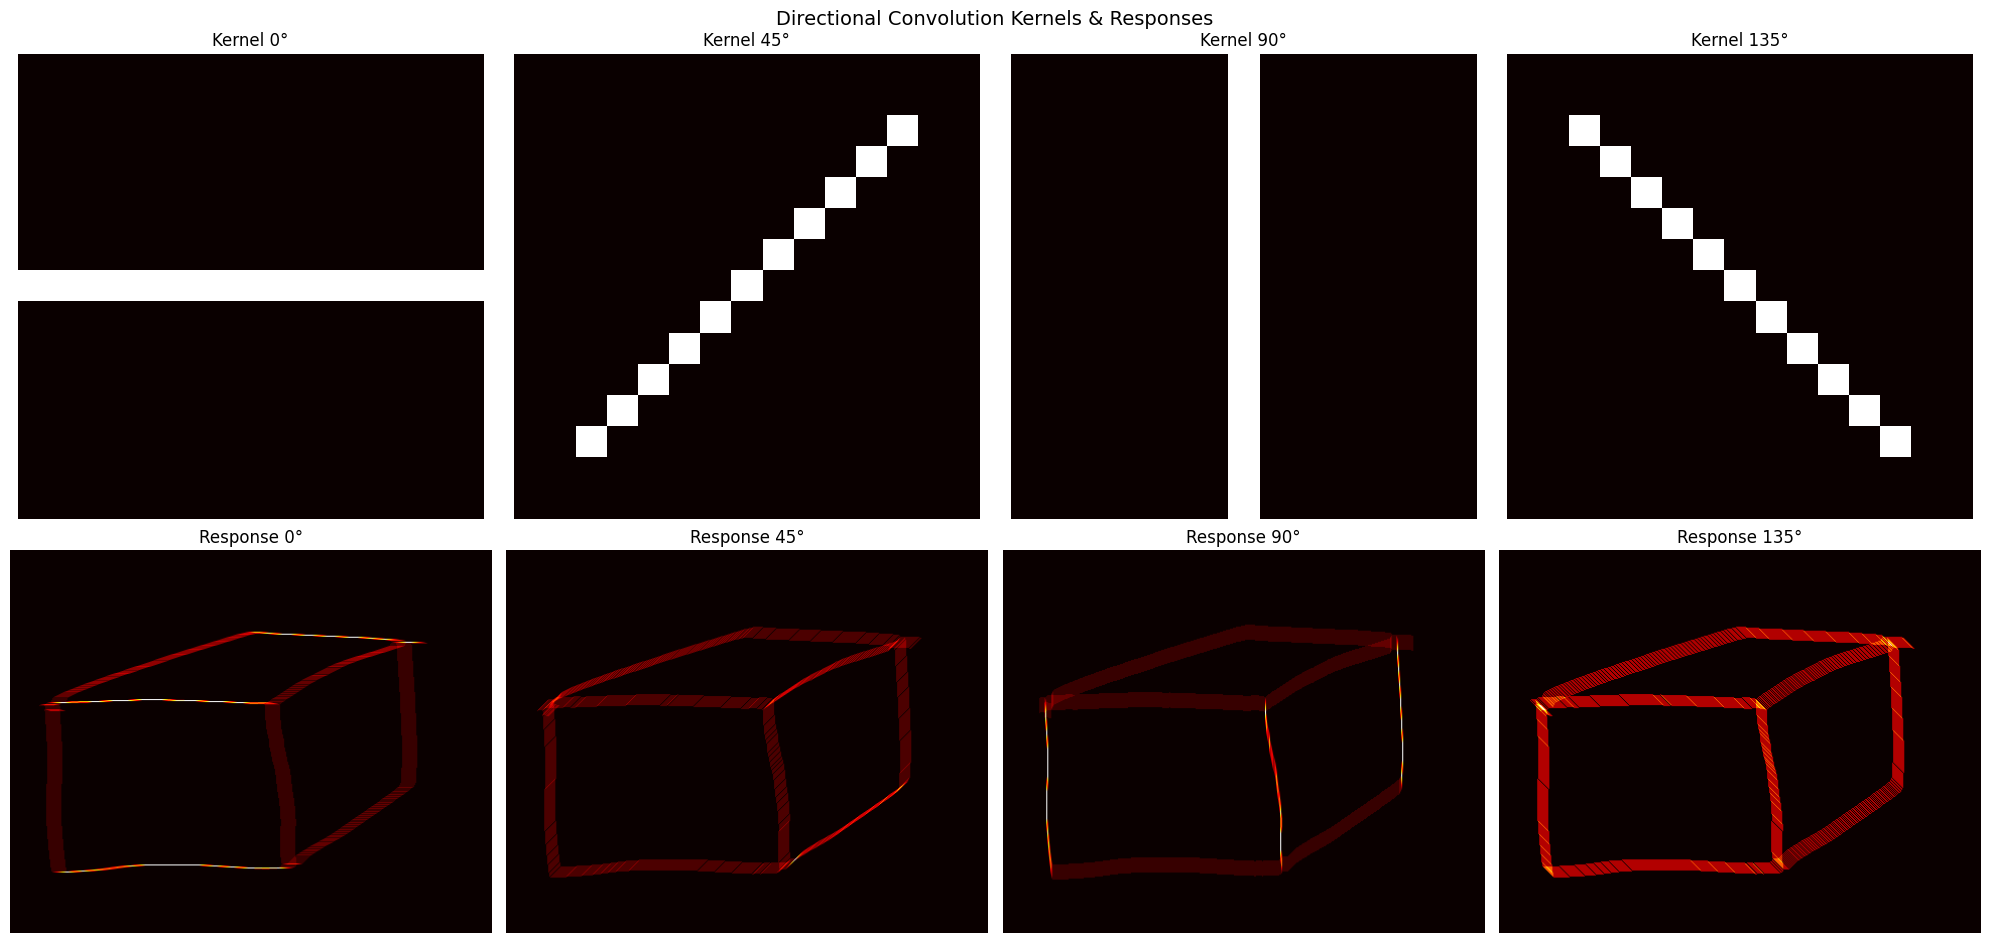

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize

img_color = cv2.imread('cuboid.png')
img_rgb = cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (5, 5), 1.5)

# --- Preprocessing: adaptive threshold + skeletonize ---
binary = cv2.adaptiveThreshold(blurred, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                               cv2.THRESH_BINARY_INV, 51, 15)
kernel_morph = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel_morph, iterations=1)

# Remove small connected components
num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)
min_area = 200
clean = np.zeros_like(binary)
for i in range(1, num_labels):
    if stats[i, cv2.CC_STAT_AREA] >= min_area:
        clean[labels == i] = 255

skeleton = skeletonize(clean > 0).astype(np.float32)

# --- Directional convolution kernels ---
# Each kernel is a line-shaped filter at a specific angle
kernel_len = 15  # length of the line kernel

def make_line_kernel(length, angle_deg):
    """Create a line-shaped convolution kernel at the given angle."""
    k = np.zeros((length, length), dtype=np.float32)
    center = length // 2
    angle_rad = np.deg2rad(angle_deg)
    for t in np.linspace(-center, center, length * 3):
        x = int(round(center + t * np.cos(angle_rad)))
        y = int(round(center - t * np.sin(angle_rad)))
        if 0 <= x < length and 0 <= y < length:
            k[y, x] = 1.0
    k /= k.sum()  # normalize
    return k

angles = [0, 45, 90, 135]
kernels = {a: make_line_kernel(kernel_len, a) for a in angles}

# Convolve skeleton with each directional kernel
responses = {}
for angle, kern in kernels.items():
    resp = cv2.filter2D(skeleton, cv2.CV_32F, kern)
    responses[angle] = resp

# --- Plot kernels and responses ---
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for idx, angle in enumerate(angles):
    axes[0, idx].imshow(kernels[angle], cmap='hot', interpolation='nearest')
    axes[0, idx].set_title(f'Kernel {angle}°')
    axes[0, idx].axis('off')
    axes[1, idx].imshow(responses[angle], cmap='hot')
    axes[1, idx].set_title(f'Response {angle}°')
    axes[1, idx].axis('off')
plt.suptitle('Directional Convolution Kernels & Responses', fontsize=14)
plt.tight_layout()
plt.show()

Line segments detected: 8


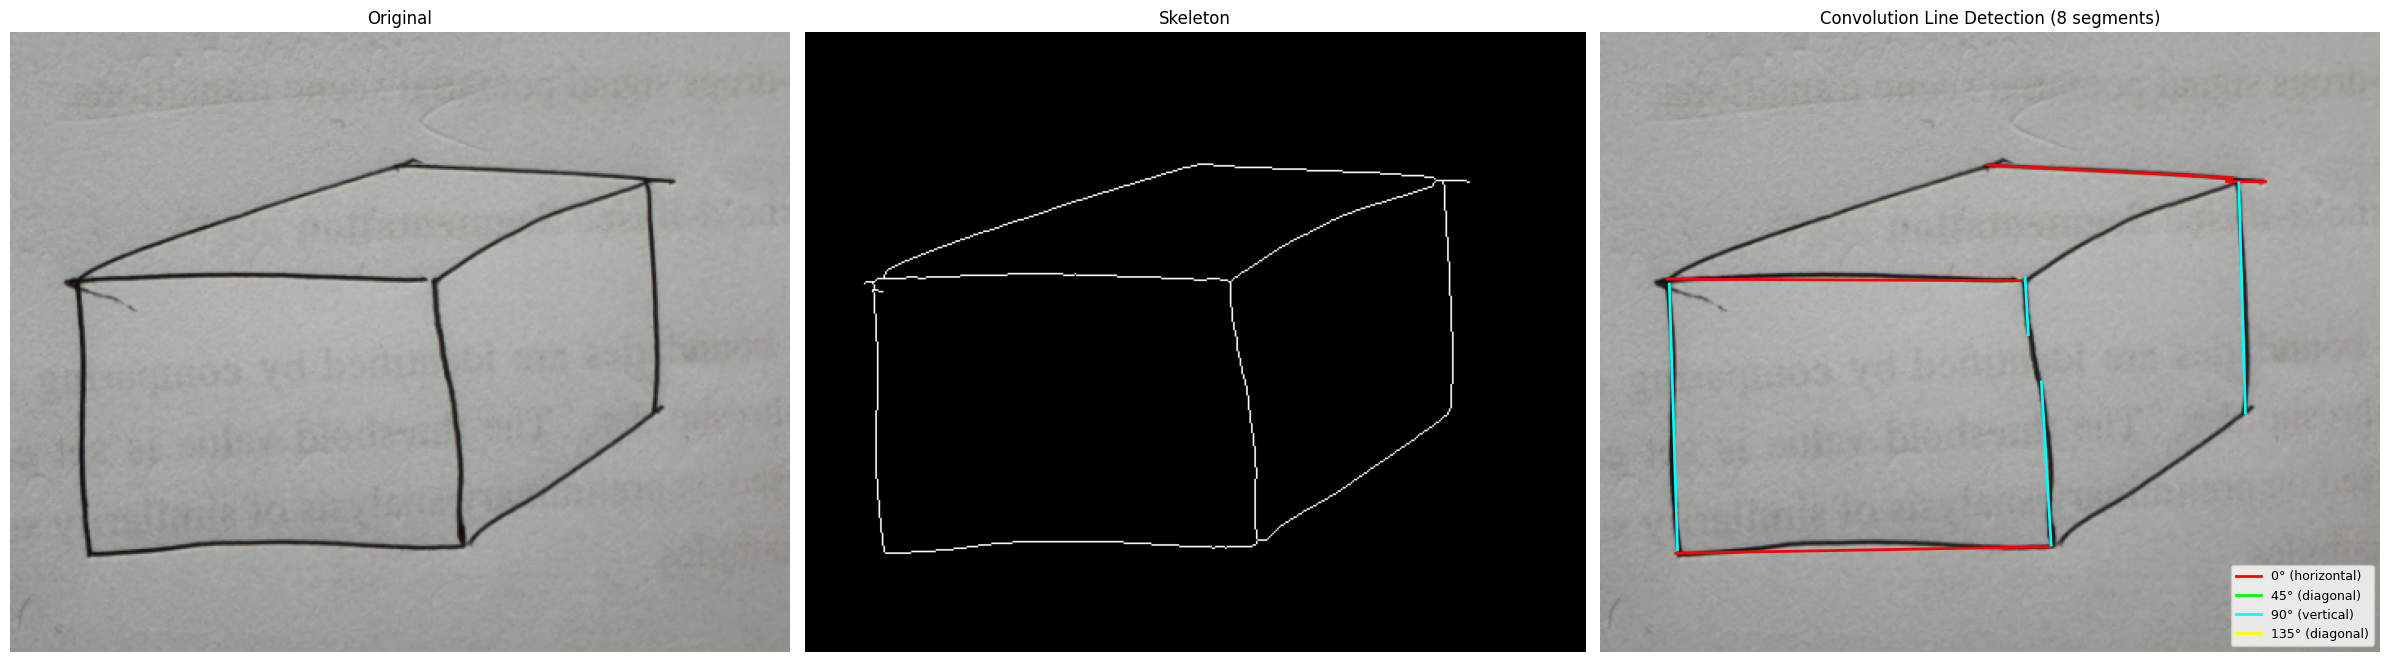

Saved result_convolution.png


In [2]:
# --- Extract dominant direction per pixel and build line segments ---
# For each pixel, pick the direction with the strongest response
response_stack = np.stack([responses[a] for a in angles], axis=-1)
dominant_dir = np.argmax(response_stack, axis=-1)
max_response = np.max(response_stack, axis=-1)

# Threshold: only keep pixels with strong response
resp_threshold = 0.3 * max_response.max()
strong_mask = max_response > resp_threshold

# --- Trace connected line segments using direction-aware grouping ---
# For each direction, find connected components in that direction's mask
line_segments = []
colors_per_dir = {0: 'red', 1: 'lime', 2: 'cyan', 3: 'yellow'}
angle_labels = {0: '0° (horizontal)', 1: '45° (diagonal)', 2: '90° (vertical)', 3: '135° (diagonal)'}

for dir_idx in range(len(angles)):
    # Mask for pixels with this dominant direction and strong enough response
    dir_mask = ((dominant_dir == dir_idx) & strong_mask).astype(np.uint8) * 255
    
    # Find connected components
    n_labels, lbl_img, comp_stats, centroids = cv2.connectedComponentsWithStats(dir_mask, connectivity=8)
    
    for comp_id in range(1, n_labels):
        area = comp_stats[comp_id, cv2.CC_STAT_AREA]
        if area < 15:  # skip tiny fragments
            continue
        ys, xs = np.where(lbl_img == comp_id)
        # Fit a line through these points: use endpoints along dominant axis
        angle = angles[dir_idx]
        if angle in (0, ):  # horizontal-ish: sort by x
            order = np.argsort(xs)
        elif angle in (90, ):  # vertical: sort by y
            order = np.argsort(ys)
        else:  # diagonal: sort by x
            order = np.argsort(xs)
        
        x1, y1 = xs[order[0]], ys[order[0]]
        x2, y2 = xs[order[-1]], ys[order[-1]]
        seg_len = np.hypot(x2 - x1, y2 - y1)
        if seg_len >= 20:
            line_segments.append((x1, y1, x2, y2, dir_idx))

print(f'Line segments detected: {len(line_segments)}')

# --- Final visualization ---
fig, axes = plt.subplots(1, 3, figsize=(24, 8))
axes[0].imshow(img_rgb); axes[0].set_title('Original'); axes[0].axis('off')
axes[1].imshow(skeleton, cmap='gray'); axes[1].set_title('Skeleton'); axes[1].axis('off')
axes[2].imshow(img_rgb)
axes[2].axis('off')

for x1, y1, x2, y2, dir_idx in line_segments:
    axes[2].plot([x1, x2], [y1, y2], color=colors_per_dir[dir_idx], linewidth=2)

# Legend
from matplotlib.lines import Line2D
legend_elems = [Line2D([0],[0], color=colors_per_dir[i], lw=2, label=angle_labels[i]) for i in range(4)]
axes[2].legend(handles=legend_elems, loc='lower right', fontsize=9)
axes[2].set_title(f'Convolution Line Detection ({len(line_segments)} segments)')

plt.tight_layout()
fig.savefig('result_convolution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved result_convolution.png')